In [1]:
%load_ext autoreload
%autoreload 2

# Feedback-period condition-averaged trajectories

For each feature X, pooled over both subjects, using the sessions where X was the rule for at least 3 blocks (as in the belief partition decoding):

- Six conditions, all on trials where X was chosen: response {correct, incorrect} x belief partition {Low, High X, High Not X}, with the belief partition taken from the prior before the trial's choice. High Not X keeps only trials where the dominant feature W was also on the chosen card (as in `prior_dependent_updates.py`).
- Activity: `firing_rates`, FeedbackOnsetLong, -0.8 s (stimulus selection) to 1.5 s after feedback onset, 100 ms bins (T = 23), no smoothing.
- Each session's trials are averaged per condition. A session is dropped for X if any condition has no trials.
- Sessions are concatenated into a matrix of shape [N, T x C], where N = neurons across sessions and C = 6 conditions. PCA is run on it with time-condition points as samples, after either z-scoring each neuron or only mean-centering it.

In [2]:
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

import utils.behavioral_utils as behavioral_utils
from constants.decoding_constants import get_trial_interval
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import BeliefPartitionConfigs
from scripts.pseudo_decoding.belief_partitions.stim_belief_vector_alignment import get_feat_to_sessions, load_session_frs
from scripts.pseudo_decoding.belief_partitions.prior_dependent_updates import label_events, TEST_CELLS

FEATS = ["ESCHER", "YELLOW", "MAGENTA", "SQUARE"]
SUBJECTS = ["SA", "BL"]
TRIAL_EVENT = "FeedbackOnsetLong"
# ms relative to feedback onset
TIME_RANGE = [-800, 1500]
# bin of feedback onset; bin 0 is stimulus selection, 800 ms before it
FB_ONSET_IDX = -TIME_RANGE[0] // get_trial_interval(TRIAL_EVENT).interval_size
FR_TYPE = "firing_rates"

# cor/Low, cor/High X, cor/High Not X, inc/Low, inc/High X, inc/High Not X
CONDS = TEST_CELLS
NORMS = ["zscore", "mean_center"]
N_PCS = 10

## Condition averages

In [3]:
def make_args(sub):
    args = argparse.Namespace(**BeliefPartitionConfigs(subject=sub, trial_event=TRIAL_EVENT, fr_type=FR_TYPE)._asdict())
    args.trial_interval = get_trial_interval(TRIAL_EVENT)
    args.time_range = TIME_RANGE
    return args


def session_cond_avgs(sess_name, feats, args):
    """
    ({feat: units x (C x T) condition averages}, per-feature condition counts) for one session.
    Columns are condition-major: CONDS[0]'s T bins, then CONDS[1]'s, and so on. A feature with
    any empty condition gets counts but no averages.
    """
    session_frs = load_session_frs(sess_name, args)
    if session_frs is None:
        return {}, []
    X, trial_pos, _ = session_frs
    beh = behavioral_utils.load_behavior_from_args(sess_name, args)

    avgs, counts = {}, []
    for feat in feats:
        events = label_events(beh, feat)
        events = events[events.TrialNumber.isin(list(trial_pos))]
        n = events.cell.value_counts().reindex(CONDS, fill_value=0)
        counts.append({"subject": args.subject, "session": sess_name, "feat": feat, "n_units": X.shape[1], **n})
        if (n == 0).any():
            continue
        avgs[feat] = np.concatenate([
            X[[trial_pos[t] for t in events[events.cell == c].TrialNumber]].mean(axis=0) for c in CONDS
        ], axis=1)
    return avgs, counts


mats = {feat: [] for feat in FEATS}
counts = []
for sub in SUBJECTS:
    args = make_args(sub)
    feat_to_sessions, _ = get_feat_to_sessions(args)
    sessions = sorted(set().union(*[feat_to_sessions[f] for f in FEATS]))
    for sess_name in sessions:
        feats = [f for f in FEATS if sess_name in feat_to_sessions[f]]
        avgs, sess_counts = session_cond_avgs(sess_name, feats, args)
        counts.extend(sess_counts)
        for feat, avg in avgs.items():
            mats[feat].append(avg)

counts = pd.DataFrame(counts)
# N x (C x T) per feature
mats = {feat: np.concatenate(m, axis=0) for feat, m in mats.items()}
T = mats[FEATS[0]].shape[1] // len(CONDS)

Sessions kept per feature (every condition non-empty), and the resulting number of neurons N.

In [4]:
counts["kept"] = (counts[CONDS] > 0).all(axis=1)
summary = counts.groupby(["feat", "subject"]).agg(sessions=("session", "size"), kept=("kept", "sum")).unstack("subject")
summary["N"] = pd.Series({feat: m.shape[0] for feat, m in mats.items()})
summary

sessions     kept        N
subject       BL  SA   BL  SA     
feat                              
ESCHER        15  17   13  17  528
MAGENTA        7  21    7  19  549
SQUARE         4  22    4  22  599
YELLOW         6  25    4  25  664

Trials per condition across sessions (all sessions, before dropping).

In [5]:
counts.groupby("feat")[CONDS].describe().T.loc[(slice(None), ["min", "50%", "max"]), :].unstack(1)

feat           ESCHER              MAGENTA              SQUARE               \
                  min   50%    max     min   50%    max    min   50%    max   
cor/Low          36.0  56.0   78.0    27.0  51.0   81.0   35.0  54.5   90.0   
cor/High X       17.0  52.5   86.0    13.0  36.5  103.0   38.0  65.5  135.0   
cor/High Not X   21.0  62.0  105.0    25.0  63.5  110.0   32.0  77.5  111.0   
inc/Low          28.0  59.5   92.0    29.0  59.0  102.0   35.0  65.5  137.0   
inc/High X        1.0   4.0    6.0     1.0   3.0    9.0    1.0   3.0    6.0   
inc/High Not X    0.0   3.0    8.0     0.0   3.0   13.0    1.0   4.0   11.0   

feat           YELLOW               
                  min   50%    max  
cor/Low          28.0  55.0   81.0  
cor/High X       24.0  62.0  112.0  
cor/High Not X   33.0  68.0   99.0  
inc/Low          46.0  67.0  129.0  
inc/High X        1.0   3.0    7.0  
inc/High Not X    0.0   4.0    7.0

## PCA

In [6]:
def normalize(M, norm):
    """Per neuron (row), over its C x T condition-average points. Zero-sd neurons go to 0 under zscore."""
    centered = M - M.mean(axis=1, keepdims=True)
    if norm == "mean_center":
        return centered
    sd = M.std(axis=1, keepdims=True)
    return np.divide(centered, sd, out=np.zeros_like(centered), where=sd > 0)


def fit_pca(M, norm):
    """(C x T x N_PCS scores, explained variance ratios), with the C x T points as samples."""
    pca = PCA(n_components=N_PCS)
    scores = pca.fit_transform(normalize(M, norm).T)
    return scores.reshape(len(CONDS), T, N_PCS), pca.explained_variance_ratio_


pcs = {(feat, norm): fit_pca(mats[feat], norm) for feat in FEATS for norm in NORMS}

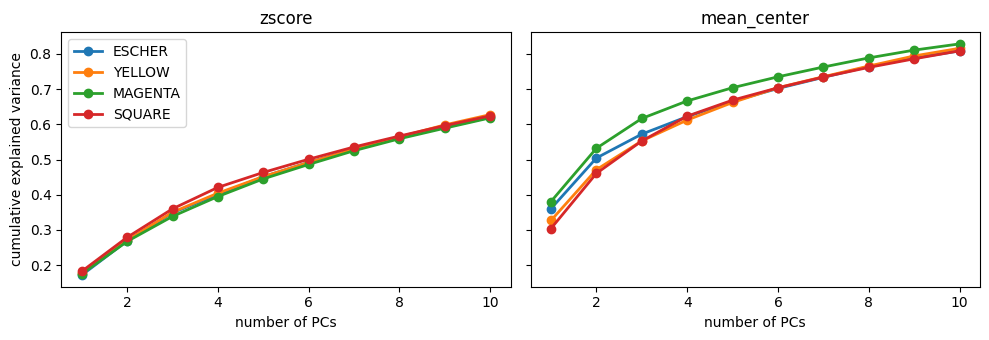

In [7]:
fig, axes = plt.subplots(1, len(NORMS), figsize=(10, 3.5), sharey=True)
for ax, norm in zip(axes, NORMS):
    for feat in FEATS:
        ax.plot(np.arange(1, N_PCS + 1), np.cumsum(pcs[(feat, norm)][1]), marker="o", lw=2, label=feat)
    ax.set_title(norm)
    ax.set_xlabel("number of PCs")
axes[0].set_ylabel("cumulative explained variance")
axes[0].legend()
fig.tight_layout()

## Trajectories

Each panel is PC i vs. PC i+1, for i = 1..9. Color is the belief partition, line style the response. The circle marks stimulus selection (first bin, -0.8 s), the triangle feedback onset, and the square the last bin (1.5 s).

In [8]:
PARTITION_COLORS = {"Low": "#2a78d6", "High X": "#eb6834", "High Not X": "#1baf7a"}
OUTCOME_STYLES = {"cor": "-", "inc": "--"}
OUTCOME_NAMES = {"cor": "correct", "inc": "incorrect"}


def plot_trajectories(feat, norm):
    scores, evr = pcs[(feat, norm)]
    fig, axes = plt.subplots(3, 3, figsize=(12, 11))
    for i, ax in enumerate(axes.flat):
        for c_idx, cond in enumerate(CONDS):
            outcome, partition = cond.split("/")
            x, y = scores[c_idx, :, i], scores[c_idx, :, i + 1]
            color = PARTITION_COLORS[partition]
            ax.plot(x, y, ls=OUTCOME_STYLES[outcome], color=color, lw=2)
            ax.plot(x[0], y[0], "o", color=color, ms=8, mec="white", mew=2)
            ax.plot(x[FB_ONSET_IDX], y[FB_ONSET_IDX], "^", color=color, ms=9, mec="white", mew=2)
            ax.plot(x[-1], y[-1], "s", color=color, ms=8, mec="white", mew=2)
        ax.set_xlabel(f"PC{i + 1} ({evr[i]:.1%})")
        ax.set_ylabel(f"PC{i + 2} ({evr[i + 1]:.1%})")
        ax.spines[["top", "right"]].set_visible(False)
    handles = (
        [Line2D([], [], color=c, lw=2, label=p) for p, c in PARTITION_COLORS.items()]
        + [Line2D([], [], color="gray", ls=s, lw=2, label=OUTCOME_NAMES[o]) for o, s in OUTCOME_STYLES.items()]
        + [Line2D([], [], color="gray", marker="o", ls="", ms=8, label="stimulus selection"),
           Line2D([], [], color="gray", marker="^", ls="", ms=9, label="feedback onset"),
           Line2D([], [], color="gray", marker="s", ls="", ms=8, label=f"{TIME_RANGE[1] / 1000:.1f} s")]
    )
    fig.legend(handles=handles, loc="upper center", ncol=len(handles), frameon=False, bbox_to_anchor=(0.5, 1.0))
    fig.suptitle(f"{feat}, {norm}, N = {mats[feat].shape[0]}", y=1.03)
    fig.tight_layout()
    return fig

### zscore

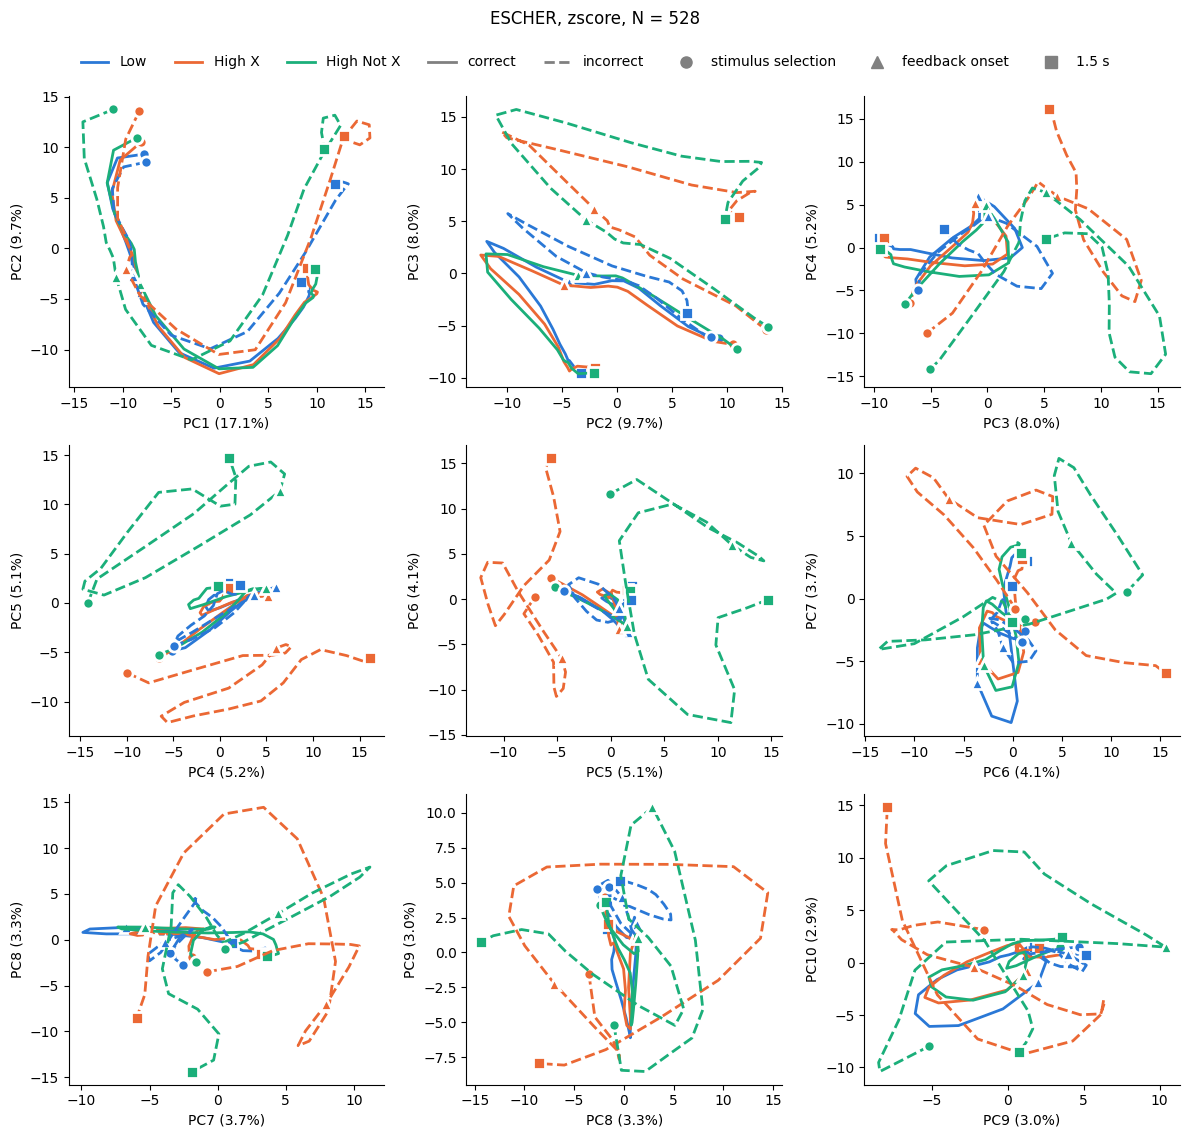

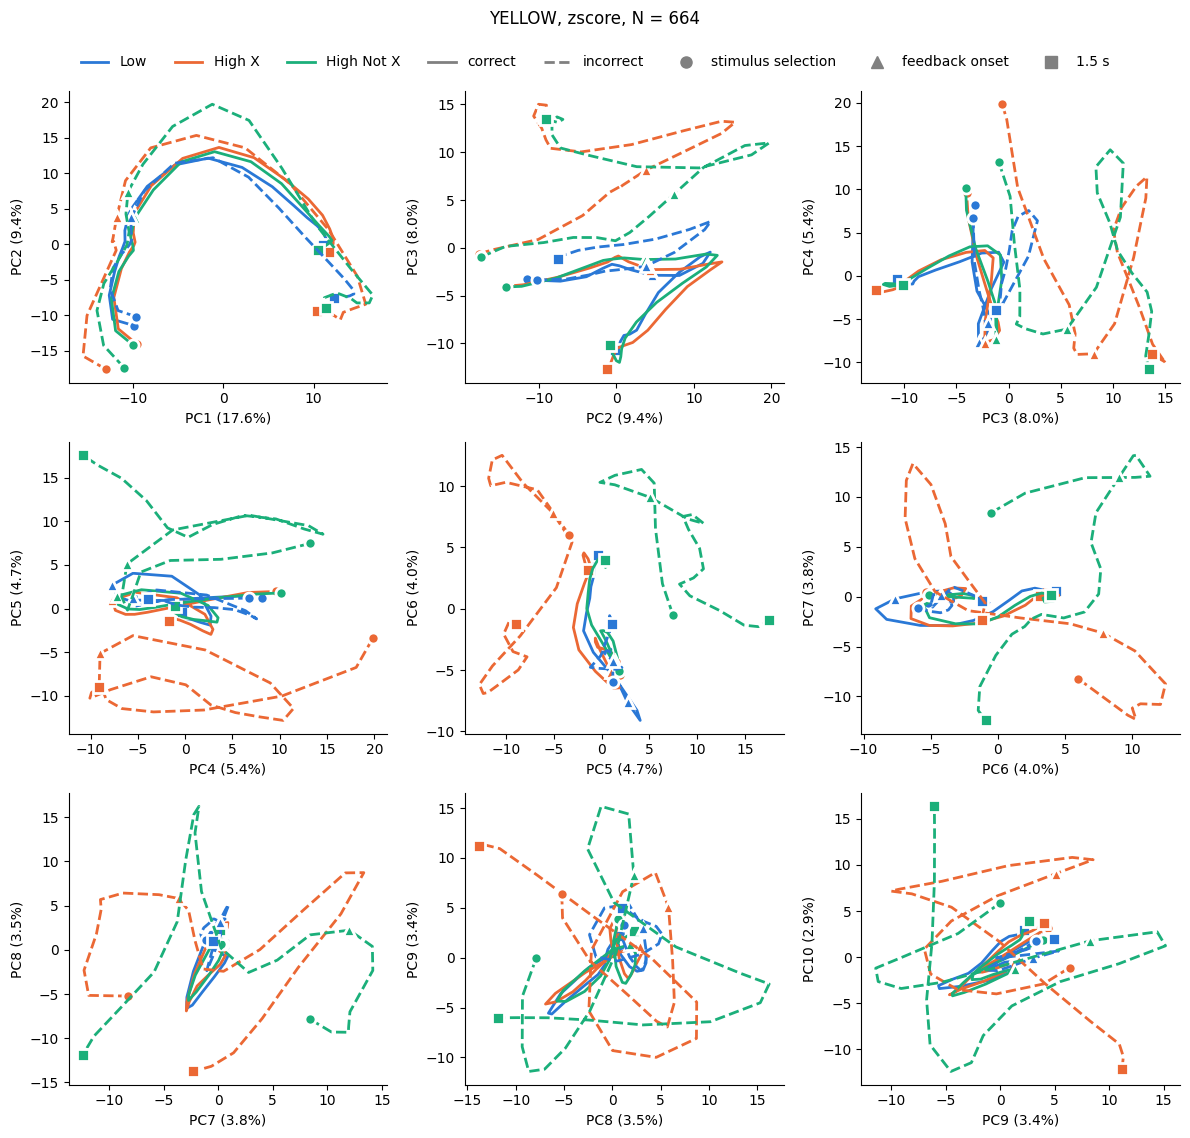

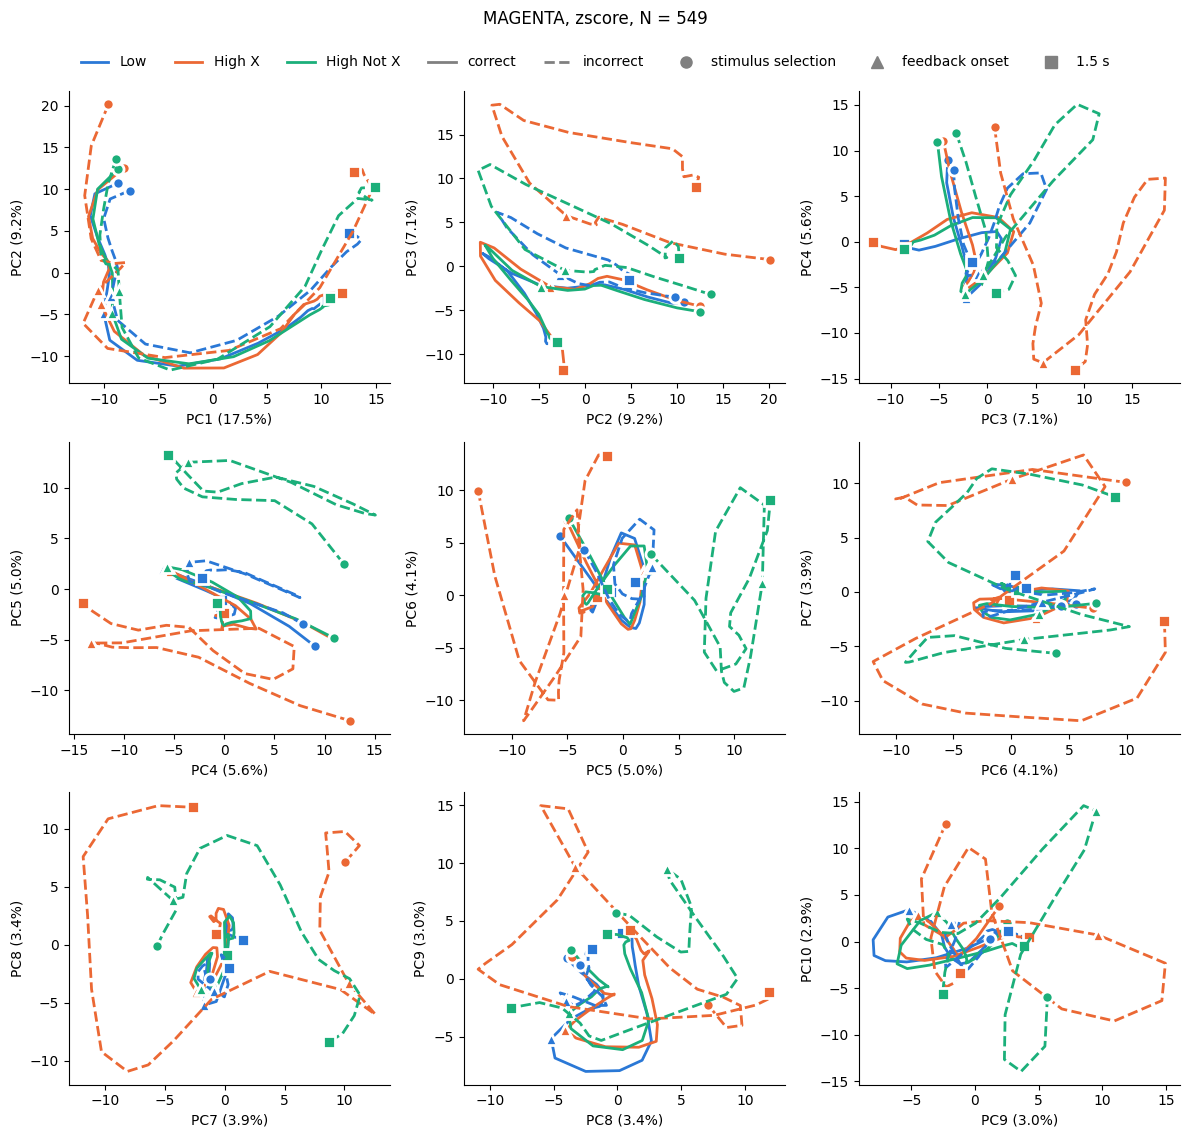

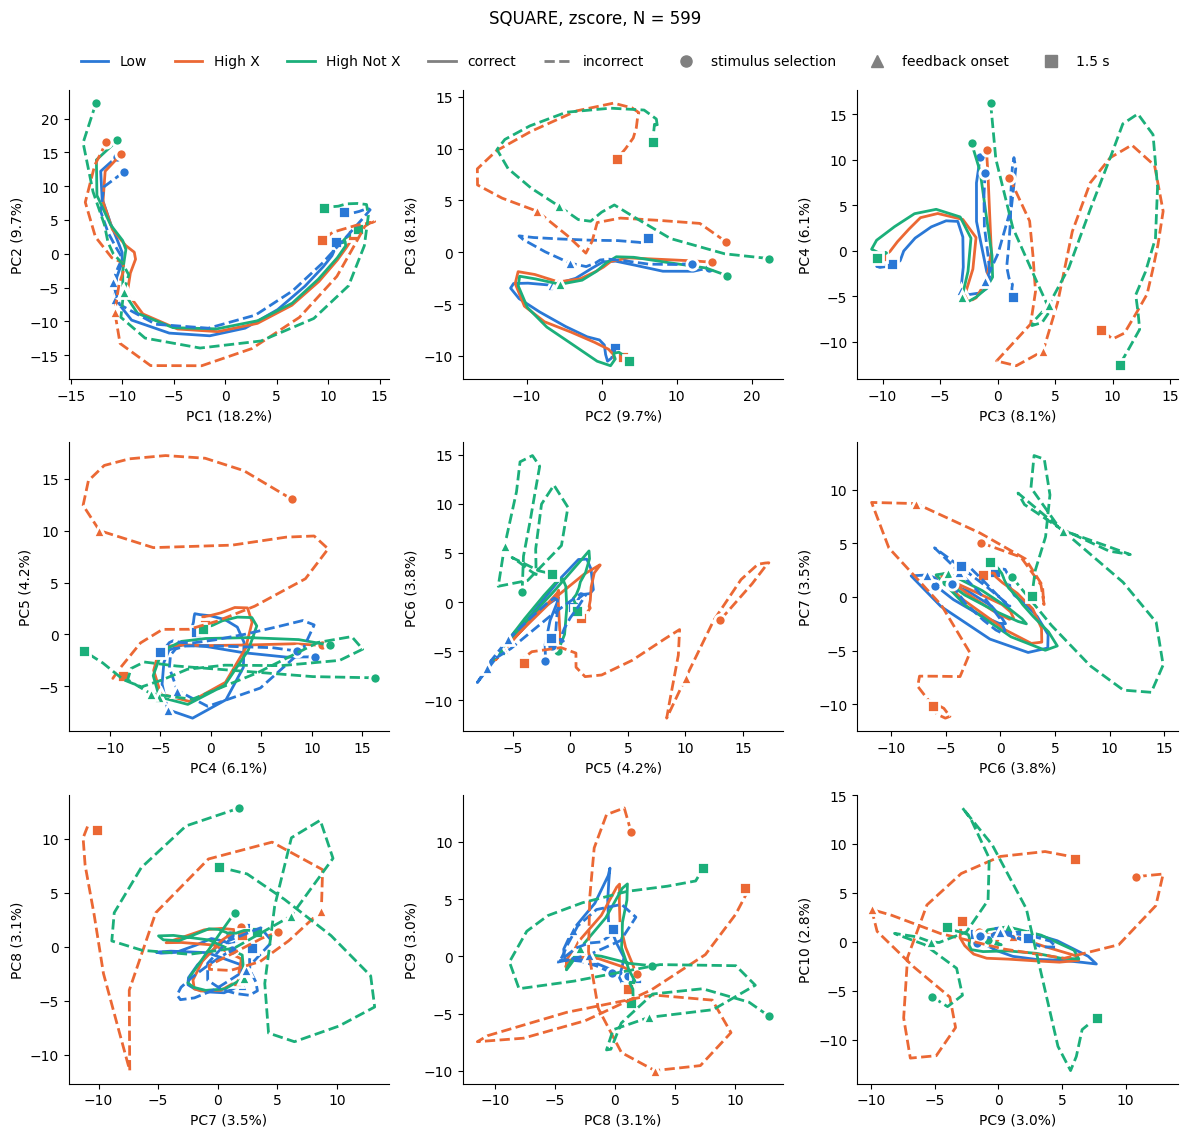

In [9]:
for feat in FEATS:
    plot_trajectories(feat, "zscore")

### mean_center

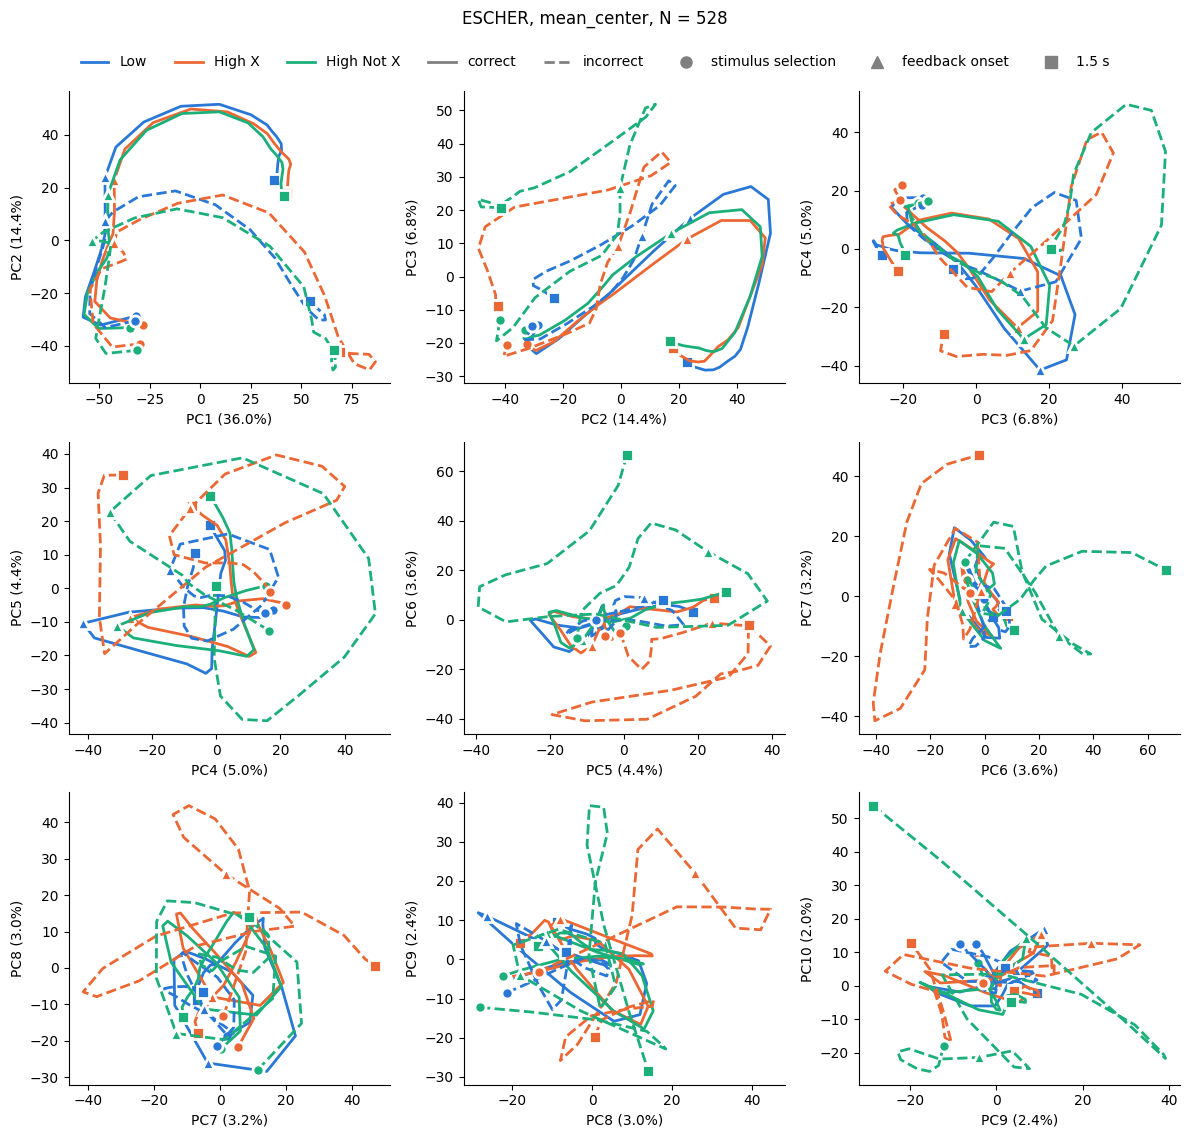

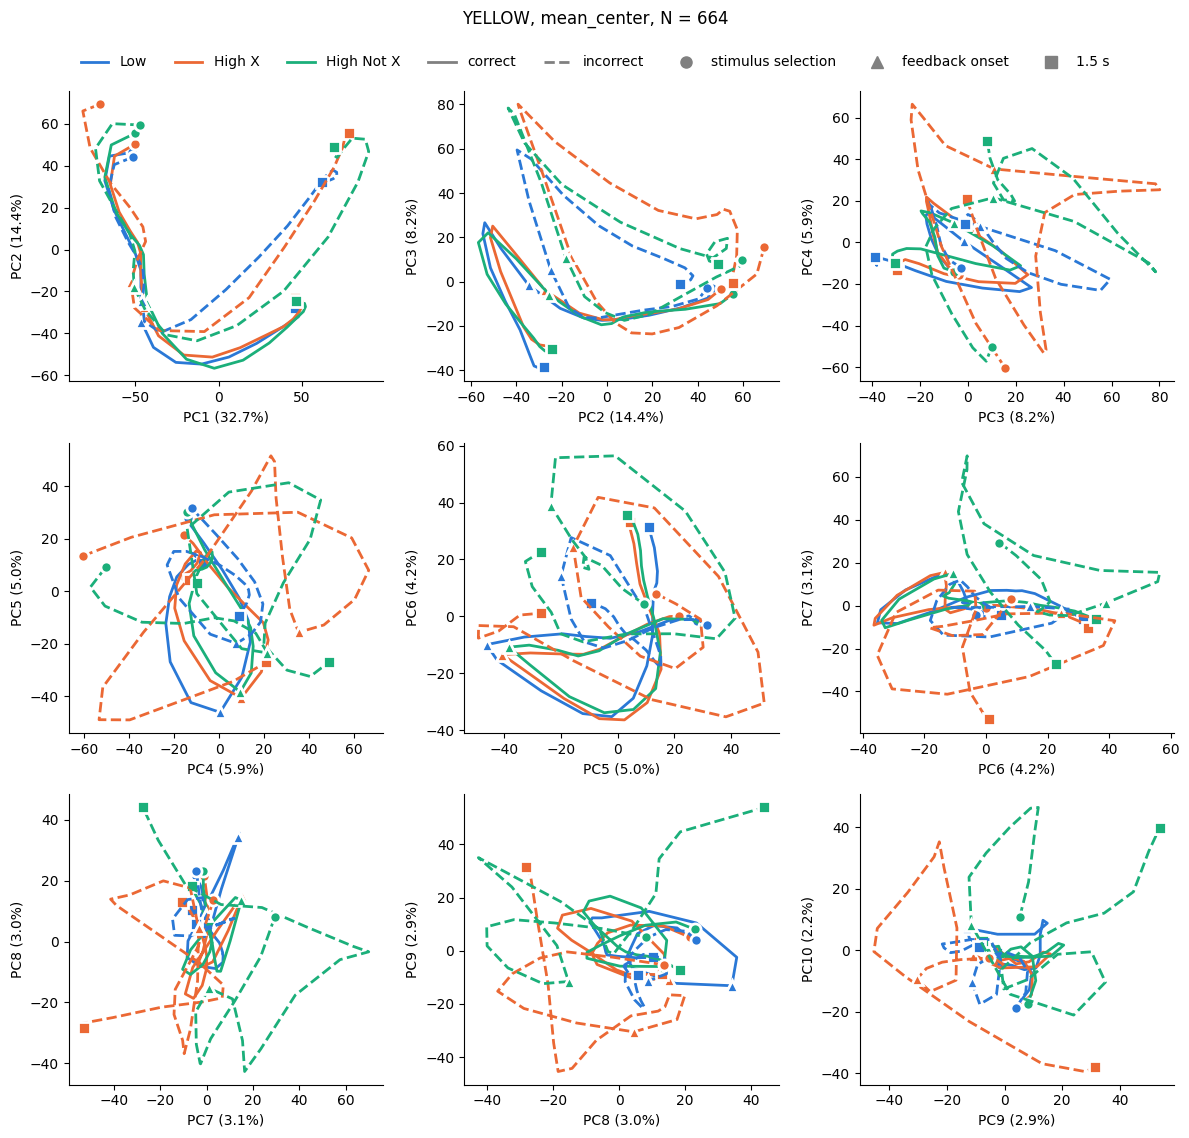

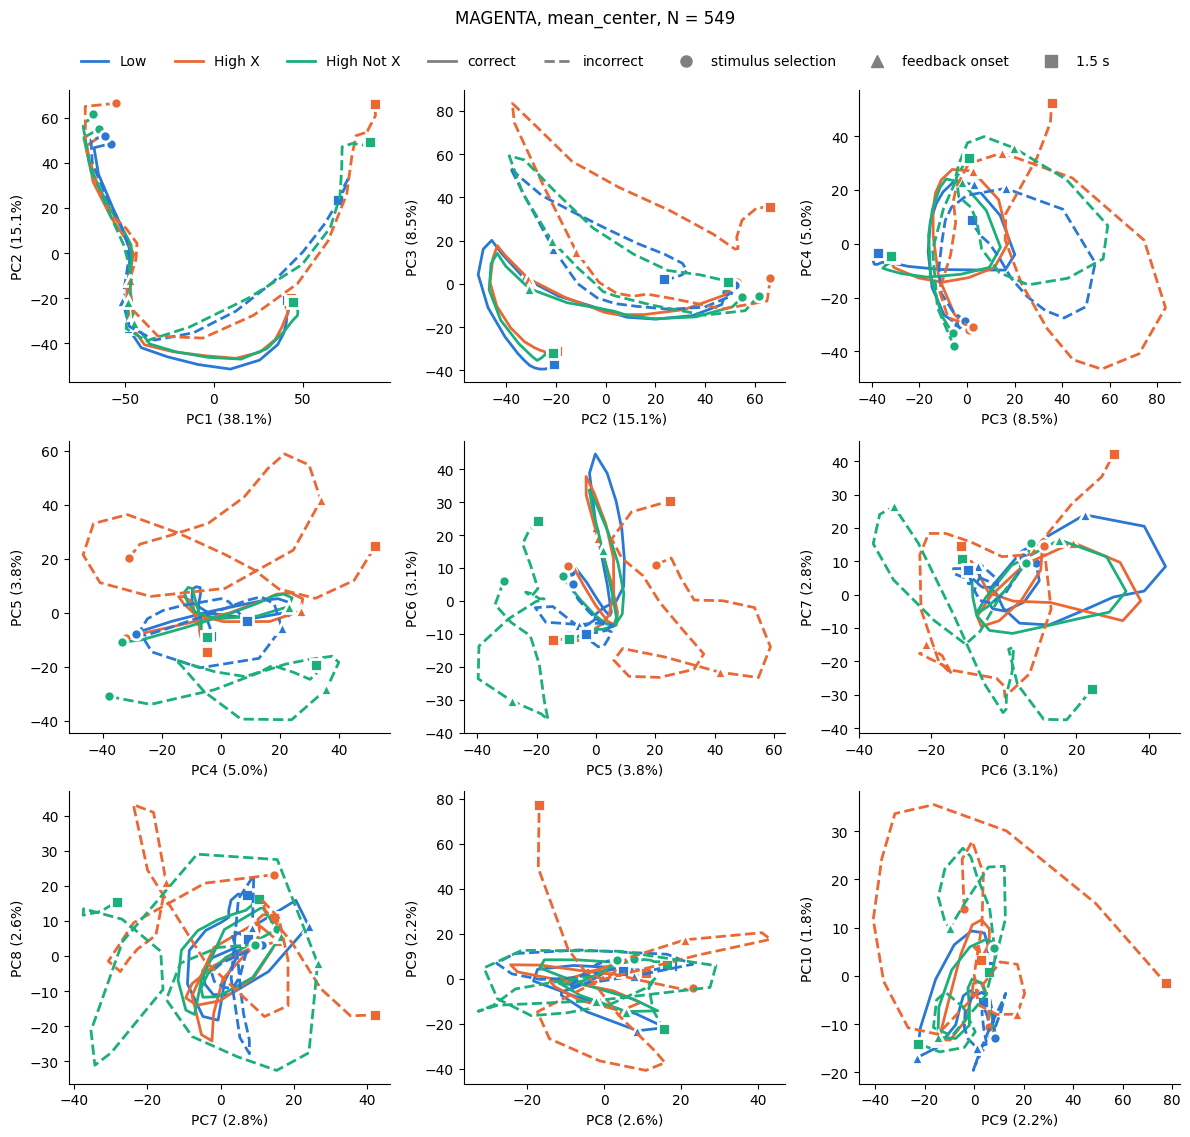

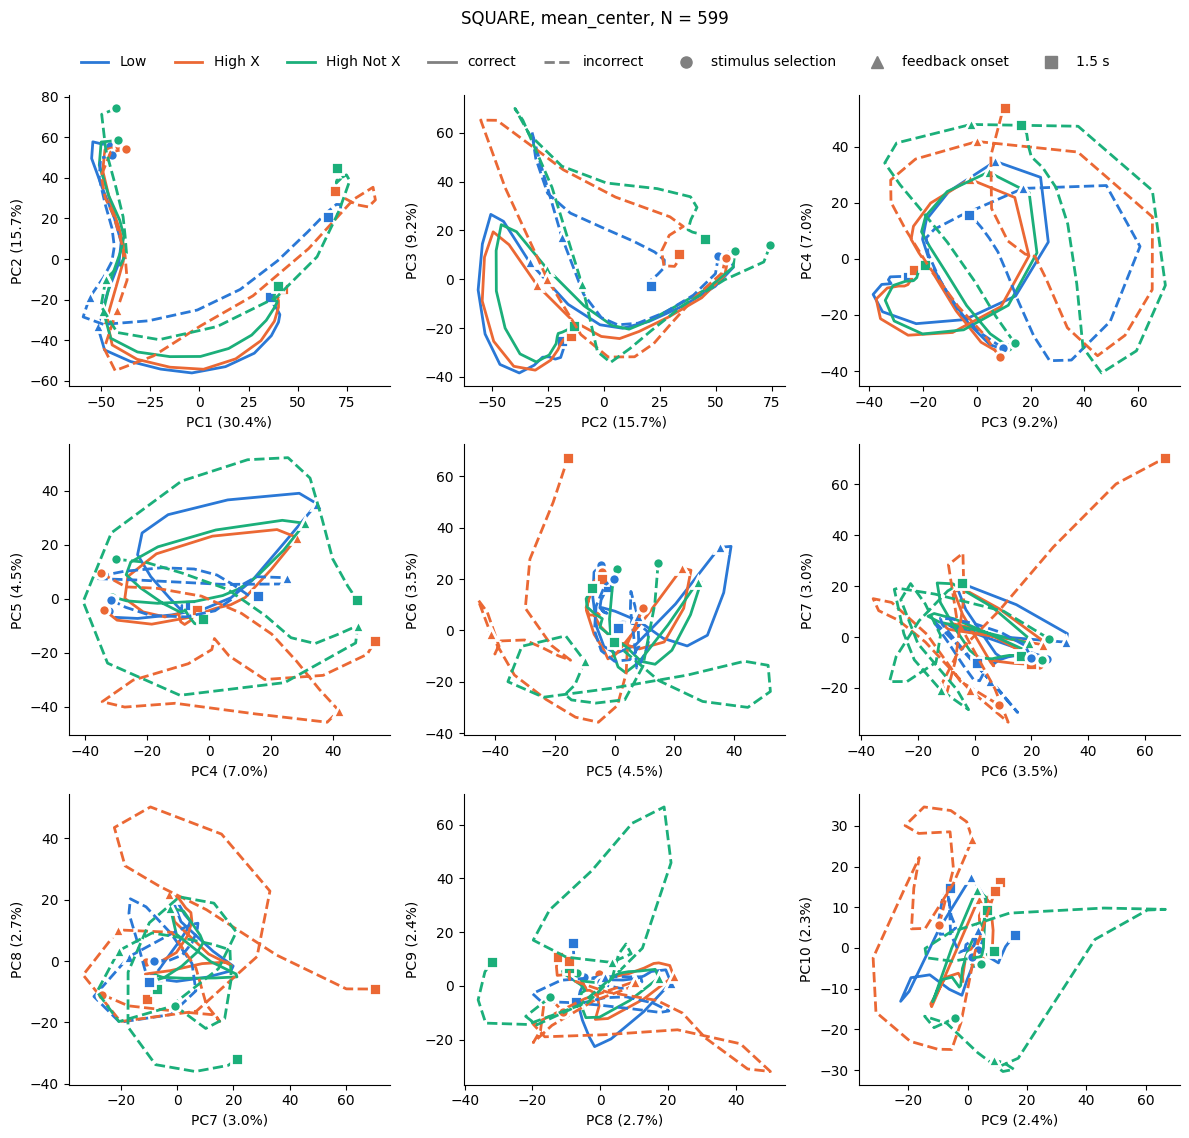

In [10]:
for feat in FEATS:
    plot_trajectories(feat, "mean_center")